<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import time
import copy

In [156]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [157]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [158]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [159]:
class_labels = train_data.classes
len(train_data), len(test_data)

(60000, 10000)

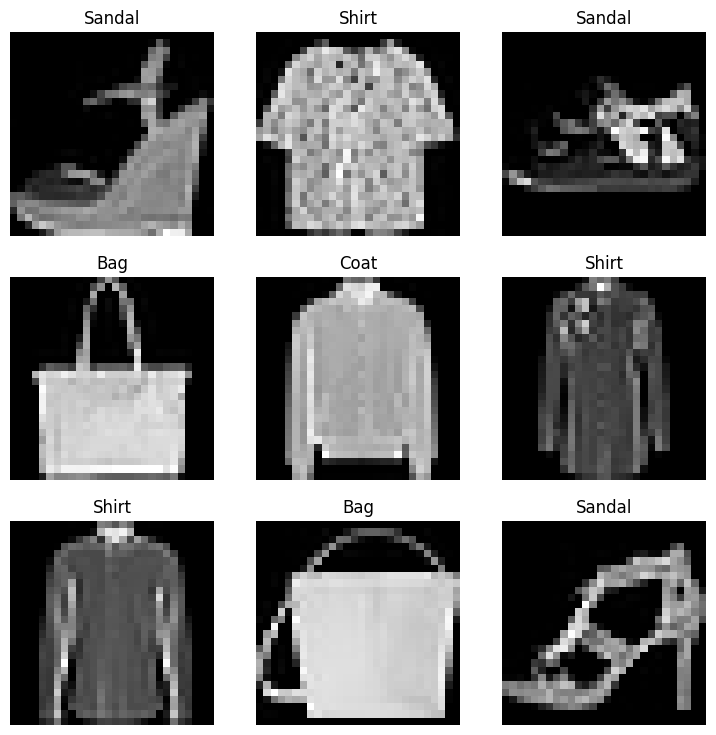

In [160]:
seed = 13
torch.manual_seed(seed)
class_map = train_data.classes
fig = plt.figure(figsize=(9,9))
rows, cols = 3, 3

for i in range(9):
    rand_idx = torch.randint(0, len(train_data), [1]).item()
    image, label = train_data[rand_idx]
    fig.add_subplot(rows, cols, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_map[label])
    plt.axis(False)

In [161]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [162]:
torch.manual_seed(13)
train_data, val_data = random_split(
    train_data,
    [5/6, 1/6]
)
print(len(train_data), len(val_data))

50000 10000


In [163]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=64, num_workers=2, pin_memory=True)

print(next(iter(train_dataloader))[0].shape)

torch.Size([64, 1, 28, 28])


In [164]:
criterion = nn.CrossEntropyLoss()

In [165]:
def train_model(model, epochs, criterion, optimizer, train_dataloader, val_dataloader, scheduler=None, device=device):
    patience = 5
    patience_counter = 0
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_params_dict = None
    best_val_loss = float('infinity')
    model.to(device)

    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for X, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            running_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()
        train_loss = running_train_loss / len(train_dataloader)
        train_losses.append(train_loss)

        model.eval()
        correct = 0
        total = 0
        running_val_loss = 0.0
        with torch.inference_mode():
            for X, y in val_dataloader:
                X, y = X.to(device), y.to(device)
                pred_logits = model(X)
                loss = criterion(pred_logits, y)
                predictions = torch.argmax(pred_logits, dim=1)
                total += y.size(0)
                correct += (y == predictions).sum().item()
                running_val_loss += loss.item()
        val_loss = running_val_loss / len(val_dataloader)
        val_losses.append(val_loss)
        acc = correct / total
        val_accuracies.append(acc)
        if scheduler is not None:
            curr_lr = f"{scheduler.get_last_lr()[0]:.4f}"
        else:
            curr_lr = "N/A"
        print(f"Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss} | Val Loss: {val_loss} | Val Accuracy: {acc} | LR: {curr_lr}")
        if (val_loss < best_val_loss):
            best_val_loss = val_loss
            best_params_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"Best Val Loss: {val_loss} | Saving state_dict...")
        else:
            patience_counter += 1

        if (patience_counter >= patience):
            print(f"Early stopping triggered. Stopping after {epoch+1}/{epochs} epochs...")
            break
    end = time.perf_counter()

    elapsed = end - start
    minutes, seconds = divmod(elapsed, 60)
    print(f"Total Training Time: {minutes}m {seconds:.2f}s")
    return best_params_dict, train_losses, val_losses, val_accuracies, best_val_loss, elapsed

In [166]:
def plot_results(train_losses, val_losses, val_accuracies):
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(train_losses, label="Train Losses")
    ax[0].plot(val_losses, label="Val Losses")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Epoch vs Loss")
    ax[0].legend()

    ax[1].plot(val_accuracies, label="Val Accuracies")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Epoch vs Validation Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [167]:
def run_validation(model, best_state_dict, val_dataloader, loss_fn, device=device):
    model.load_state_dict(best_state_dict)
    model.to(device)
    model.eval()
    predicted_labels = []
    true_labels = []
    total_val_loss = 0.0
    with torch.inference_mode():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_val_loss += loss_fn(logits, y).item()
            preds = torch.argmax(logits, dim=1)
            predicted_labels.extend(preds.cpu().tolist())
            true_labels.extend(y.cpu().tolist())
    acc = accuracy_score(true_labels, predicted_labels)
    cm = confusion_matrix(true_labels, predicted_labels)
    avg_val_loss = total_val_loss/len(val_dataloader)
    print(classification_report(true_labels, predicted_labels))
    print(f"val Accuracy: {acc:.2f} | val Loss: {avg_val_loss:.4f}")
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot()

    plt.show()
    return acc, avg_val_loss

In [168]:
def reset_model_params(model):
    torch.manual_seed(13)
    model.apply(
        lambda m: m.reset_parameters()
        if hasattr(m, "reset_parameters")
        else None
    )

In [169]:
torch.manual_seed(13)
model_1 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 1024),
    nn.ReLU(),

    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Linear(512, 10)
)

model_1.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=1e-3, weight_decay=1e-5)]

In [170]:
torch.manual_seed(13)

model_2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

model_2.optimizers = [lambda params: torch.optim.SGD(params=params, lr=0.05, momentum=0.9),
                      lambda params: torch.optim.SGD(params=params, lr=0.1, momentum=0.9),
                      lambda params: torch.optim.AdamW(params=params, lr=1e-2, weight_decay=1e-5)]

In [171]:
torch.manual_seed(13)

model_3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(64, 10)
)

model_3.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=1e-3, weight_decay=1e-3)]

In [172]:
torch.manual_seed(13)

model_4 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2,2),

    nn.AdaptiveAvgPool2d(2),
    nn.Flatten(),
    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

model_4.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=1e-3, weight_decay=1e-5)]

In [173]:
torch.manual_seed(13)

model_5 = nn.Sequential( # just dropout with model_1
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 1024),
    nn.ReLU(),

    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(p=0.3),
    nn.Linear(512, 10)
)

model_5.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=5e-4, weight_decay=1e-5)]
model_5.lr_scheduler =  torch.optim.lr_scheduler.CosineAnnealingLR


In [174]:
torch.manual_seed(13)

model_6 = nn.Sequential( # smaller fully connected network than model_5, dropout of 0.4
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 256),
    nn.ReLU(),

    nn.Dropout(p=0.4),
    nn.Linear(256, 10)
)

model_6.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=5e-4, weight_decay=1e-5)]
model_6.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

In [175]:
torch.manual_seed(13)

model_7 = nn.Sequential( # exactly the same network as model_6, but with a dropout of 0.5
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*7*7, 256),
    nn.ReLU(),

    nn.Dropout(p=0.5),
    nn.Linear(256, 10)
)

model_7.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=5e-4, weight_decay=1e-5)]
model_7.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

In [176]:
torch.manual_seed(13)

model_8 = nn.Sequential( # exactly the same network as model_6, but with a dropout of 0.6
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(128*3*3, 256),
    nn.ReLU(),

    nn.Dropout(p=0.5),
    nn.Linear(256, 10)
)

model_8.optimizers = [lambda params: torch.optim.AdamW(params=params, lr=5e-4, weight_decay=1e-5)]
model_8.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR

In [177]:
models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5,
    "Model 6": model_6,
    "Model 7": model_7,
    "Model 8": model_8
}
model_stats = {
    "Model": [],
    "Optimizer": [],
    "Val Accuracy": [],
    "Val Loss": [],
    "Train Time": []
}



-------------------  Model 1, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 90.71it/s] 


Epoch: 1/20 | Train Loss: 0.40341459706311333 | Val Loss: 0.2920408676004714 | Val Accuracy: 0.8941 | LR: N/A
Best Val Loss: 0.2920408676004714 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:08<00:00, 95.34it/s]


Epoch: 2/20 | Train Loss: 0.2669341529688567 | Val Loss: 0.25794833291108443 | Val Accuracy: 0.9073 | LR: N/A
Best Val Loss: 0.25794833291108443 | Saving state_dict...


...

Epoch: 8/20 | Train Loss: 0.10348632807731438 | Val Loss: 0.25616713703437977 | Val Accuracy: 0.924 | LR: N/A


Epoch 9/20: 100%|██████████| 782/782 [00:08<00:00, 89.47it/s] 


Epoch: 9/20 | Train Loss: 0.0895704932566232 | Val Loss: 0.27686980967024327 | Val Accuracy: 0.9176 | LR: N/A


Epoch 10/20: 100%|██████████| 782/782 [00:08<00:00, 90.50it/s]


Epoch: 10/20 | Train Loss: 0.07976694963574696 | Val Loss: 0.2682502296142233 | Val Accuracy: 0.9257 | LR: N/A
Early stopping triggered. Stopping after 10/20 epochs...
Total Training Time: 1.0m 37.17s
Model Training Done...



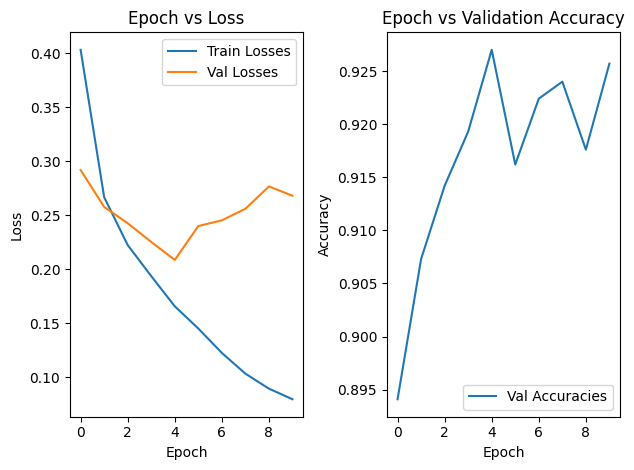

Running Validation...

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       996
           1       1.00      0.98      0.99      1029
           2       0.90      0.88      0.89      1016
           3       0.92      0.95      0.93       987
           4       0.91      0.88      0.90      1011
           5       0.99      0.98      0.98      1030
           6       0.79      0.80      0.79      1003
           7       0.97      0.95      0.96      1009
           8       0.98      1.00      0.99       938
           9       0.95      0.97      0.96       981

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

val Accuracy: 0.93 | val Loss: 0.2089


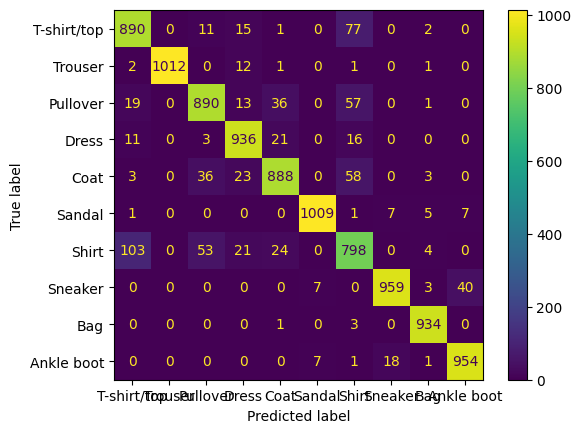



-------------------  Model 2, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 96.57it/s]


Epoch: 1/20 | Train Loss: 0.7703422809119724 | Val Loss: 0.7115711529923093 | Val Accuracy: 0.7445 | LR: N/A
Best Val Loss: 0.7115711529923093 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:07<00:00, 105.41it/s]


Epoch: 2/20 | Train Loss: 0.4972971415961795 | Val Loss: 0.48511490928139656 | Val Accuracy: 0.8297 | LR: N/A
Best Val Loss: 0.48511490928139656 | Saving state_dict...


...

Epoch: 17/20 | Train Loss: 0.27079346509235896 | Val Loss: 0.3552718821224893 | Val Accuracy: 0.8742 | LR: N/A


Epoch 18/20: 100%|██████████| 782/782 [00:08<00:00, 96.50it/s] 


Epoch: 18/20 | Train Loss: 0.263444798472135 | Val Loss: 0.35103719847597137 | Val Accuracy: 0.8788 | LR: N/A


Epoch 19/20: 100%|██████████| 782/782 [00:07<00:00, 98.30it/s]


Epoch: 19/20 | Train Loss: 0.26359584019578935 | Val Loss: 0.3556885730688739 | Val Accuracy: 0.8747 | LR: N/A
Early stopping triggered. Stopping after 19/20 epochs...
Total Training Time: 2.0m 55.06s
Model Training Done...



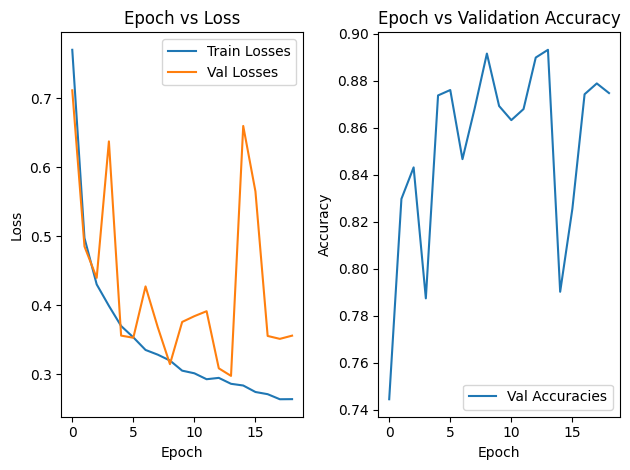

Running Validation...

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       996
           1       0.99      0.98      0.98      1029
           2       0.80      0.89      0.84      1016
           3       0.92      0.89      0.90       987
           4       0.90      0.74      0.81      1011
           5       0.91      0.98      0.95      1030
           6       0.72      0.73      0.73      1003
           7       0.93      0.97      0.95      1009
           8       0.99      0.97      0.98       938
           9       0.99      0.90      0.94       981

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000

val Accuracy: 0.89 | val Loss: 0.2966


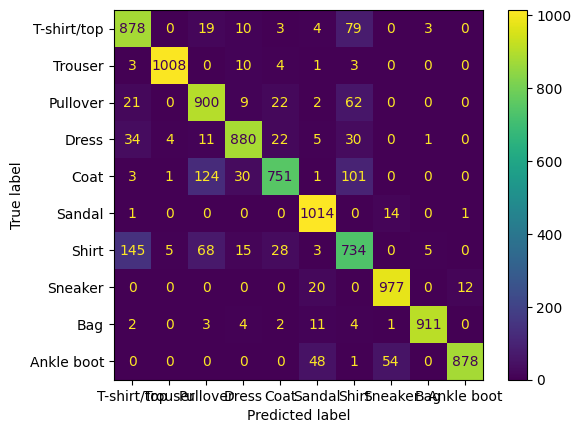



-------------------  Model 2, Optimizer 1  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:07<00:00, 105.58it/s]


Epoch: 1/20 | Train Loss: 0.718816499537824 | Val Loss: 1.100953505487199 | Val Accuracy: 0.6682 | LR: N/A
Best Val Loss: 1.100953505487199 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:07<00:00, 105.51it/s]


Epoch: 2/20 | Train Loss: 0.47635954225917 | Val Loss: 0.7137276384101552 | Val Accuracy: 0.7612 | LR: N/A
Best Val Loss: 0.7137276384101552 | Saving state_dict...


...

Epoch: 18/20 | Train Loss: 0.2592548962939731 | Val Loss: 0.30492477783351946 | Val Accuracy: 0.8912 | LR: N/A


Epoch 19/20: 100%|██████████| 782/782 [00:07<00:00, 106.30it/s]


Epoch: 19/20 | Train Loss: 0.2553556441565228 | Val Loss: 0.30726339388045537 | Val Accuracy: 0.8925 | LR: N/A


Epoch 20/20: 100%|██████████| 782/782 [00:07<00:00, 101.06it/s]


Epoch: 20/20 | Train Loss: 0.25312087948784195 | Val Loss: 0.2845365031129995 | Val Accuracy: 0.902 | LR: N/A
Best Val Loss: 0.2845365031129995 | Saving state_dict...
Total Training Time: 3.0m 3.45s
Model Training Done...



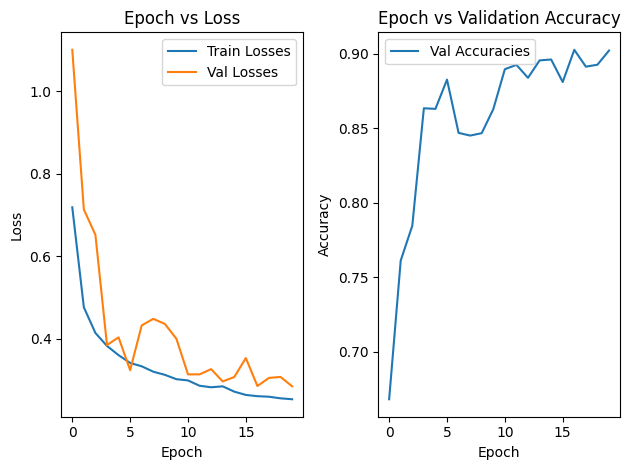

Running Validation...

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       996
           1       1.00      0.94      0.97      1029
           2       0.92      0.79      0.85      1016
           3       0.80      0.96      0.87       987
           4       0.86      0.86      0.86      1011
           5       0.98      0.98      0.98      1030
           6       0.74      0.74      0.74      1003
           7       0.96      0.96      0.96      1009
           8       0.97      0.99      0.98       938
           9       0.96      0.97      0.96       981

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

val Accuracy: 0.90 | val Loss: 0.2837


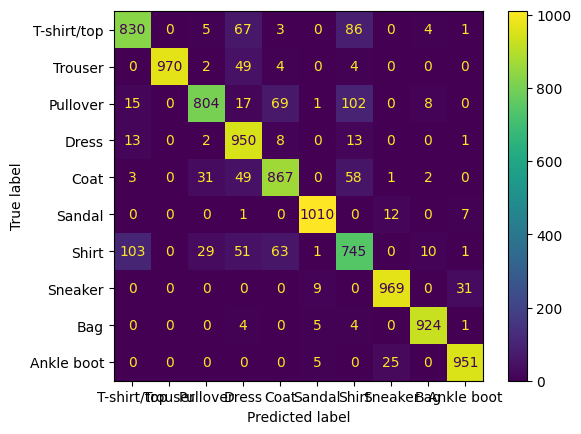



-------------------  Model 2, Optimizer 2  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 89.33it/s] 


Epoch: 1/20 | Train Loss: 0.7065853690323622 | Val Loss: 0.68565412008079 | Val Accuracy: 0.7509 | LR: N/A
Best Val Loss: 0.68565412008079 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:08<00:00, 91.22it/s] 


Epoch: 2/20 | Train Loss: 0.46843147199705737 | Val Loss: 0.5111128070931525 | Val Accuracy: 0.8138 | LR: N/A
Best Val Loss: 0.5111128070931525 | Saving state_dict...


...

Epoch: 15/20 | Train Loss: 0.26699162562332496 | Val Loss: 0.35239794204948816 | Val Accuracy: 0.8767 | LR: N/A


Epoch 16/20: 100%|██████████| 782/782 [00:07<00:00, 99.21it/s] 


Epoch: 16/20 | Train Loss: 0.26509538988399384 | Val Loss: 0.3494688988111581 | Val Accuracy: 0.8801 | LR: N/A


Epoch 17/20: 100%|██████████| 782/782 [00:08<00:00, 92.75it/s] 


Epoch: 17/20 | Train Loss: 0.2604642932963036 | Val Loss: 0.4134634384873566 | Val Accuracy: 0.8465 | LR: N/A
Early stopping triggered. Stopping after 17/20 epochs...
Total Training Time: 2.0m 42.18s
Model Training Done...



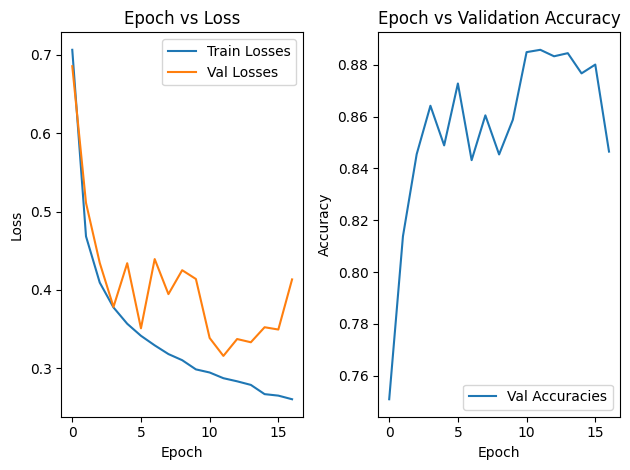

Running Validation...

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       996
           1       0.91      0.99      0.95      1029
           2       0.88      0.82      0.85      1016
           3       0.94      0.82      0.87       987
           4       0.74      0.93      0.82      1011
           5       0.99      0.94      0.96      1030
           6       0.85      0.54      0.66      1003
           7       0.94      0.97      0.95      1009
           8       0.99      0.97      0.98       938
           9       0.94      0.97      0.95       981

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000

val Accuracy: 0.89 | val Loss: 0.3162


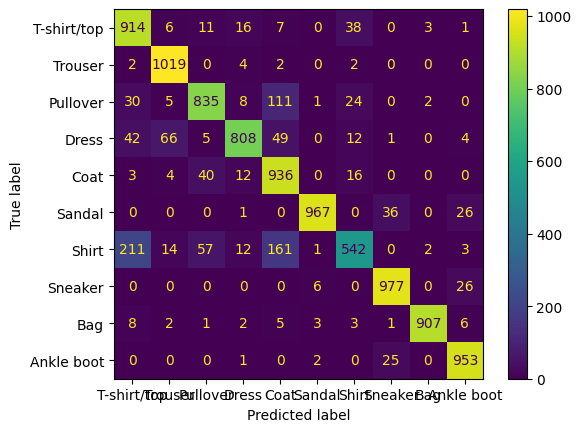



-------------------  Model 3, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 90.42it/s] 


Epoch: 1/20 | Train Loss: 1.0509209152682664 | Val Loss: 0.7779240369037458 | Val Accuracy: 0.7281 | LR: N/A
Best Val Loss: 0.7779240369037458 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:08<00:00, 88.76it/s]


Epoch: 2/20 | Train Loss: 0.6494833906669446 | Val Loss: 0.6230662446113149 | Val Accuracy: 0.7872 | LR: N/A
Best Val Loss: 0.6230662446113149 | Saving state_dict...


...

Epoch: 17/20 | Train Loss: 0.323779435547264 | Val Loss: 0.4564426355301195 | Val Accuracy: 0.8381 | LR: N/A


Epoch 18/20: 100%|██████████| 782/782 [00:08<00:00, 87.38it/s] 


Epoch: 18/20 | Train Loss: 0.31792959568979184 | Val Loss: 0.38930583294409854 | Val Accuracy: 0.8568 | LR: N/A


Epoch 19/20: 100%|██████████| 782/782 [00:08<00:00, 94.77it/s]


Epoch: 19/20 | Train Loss: 0.3130450475093959 | Val Loss: 0.381172782106764 | Val Accuracy: 0.8659 | LR: N/A
Early stopping triggered. Stopping after 19/20 epochs...
Total Training Time: 3.0m 5.48s
Model Training Done...



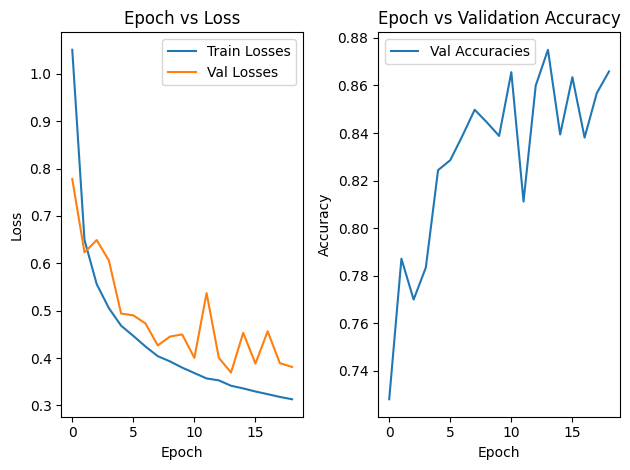

Running Validation...

              precision    recall  f1-score   support

           0       0.77      0.86      0.82       996
           1       0.99      0.96      0.97      1029
           2       0.81      0.85      0.83      1016
           3       0.83      0.93      0.88       987
           4       0.80      0.85      0.82      1011
           5       0.89      0.98      0.93      1030
           6       0.80      0.57      0.66      1003
           7       0.92      0.97      0.94      1009
           8       0.99      0.96      0.97       938
           9       0.99      0.83      0.90       981

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000

val Accuracy: 0.88 | val Loss: 0.3687


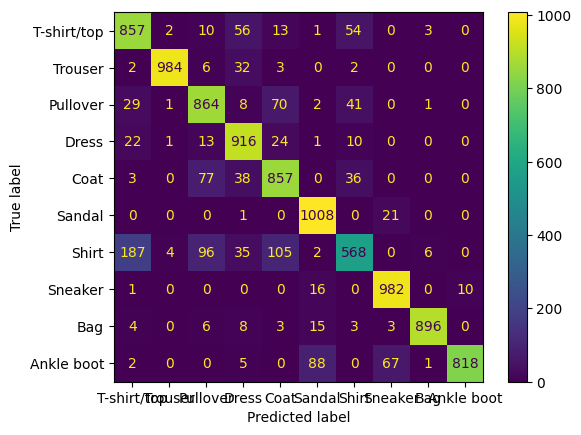



-------------------  Model 4, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 97.48it/s]


Epoch: 1/20 | Train Loss: 0.652982455137593 | Val Loss: 0.435623403852153 | Val Accuracy: 0.8449 | LR: N/A
Best Val Loss: 0.435623403852153 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:08<00:00, 94.92it/s]


Epoch: 2/20 | Train Loss: 0.41759833687787773 | Val Loss: 0.40408151516109514 | Val Accuracy: 0.8493 | LR: N/A
Best Val Loss: 0.40408151516109514 | Saving state_dict...


...

Epoch: 15/20 | Train Loss: 0.21601065377826276 | Val Loss: 0.25512476569148385 | Val Accuracy: 0.9087 | LR: N/A


Epoch 16/20: 100%|██████████| 782/782 [00:08<00:00, 88.25it/s]


Epoch: 16/20 | Train Loss: 0.20865829274668107 | Val Loss: 0.27196158210088495 | Val Accuracy: 0.9011 | LR: N/A


Epoch 17/20: 100%|██████████| 782/782 [00:09<00:00, 86.32it/s] 


Epoch: 17/20 | Train Loss: 0.20494401490177644 | Val Loss: 0.25577602957843976 | Val Accuracy: 0.9056 | LR: N/A
Early stopping triggered. Stopping after 17/20 epochs...
Total Training Time: 2.0m 50.12s
Model Training Done...



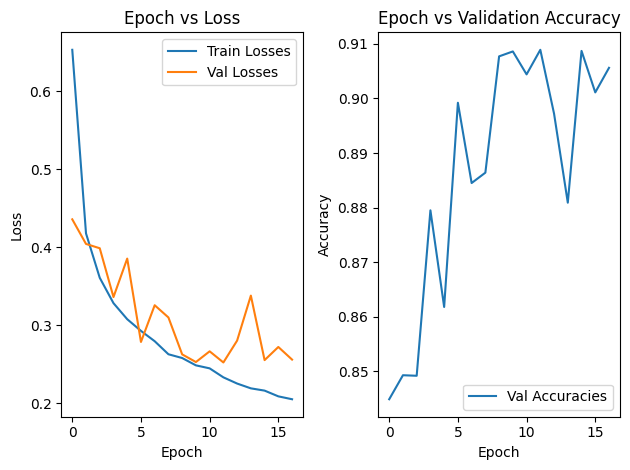

Running Validation...

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       996
           1       1.00      0.97      0.98      1029
           2       0.86      0.87      0.86      1016
           3       0.86      0.96      0.90       987
           4       0.93      0.81      0.87      1011
           5       0.98      0.98      0.98      1030
           6       0.74      0.78      0.76      1003
           7       0.91      0.99      0.95      1009
           8       0.98      0.99      0.99       938
           9       0.99      0.90      0.94       981

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

val Accuracy: 0.91 | val Loss: 0.2554


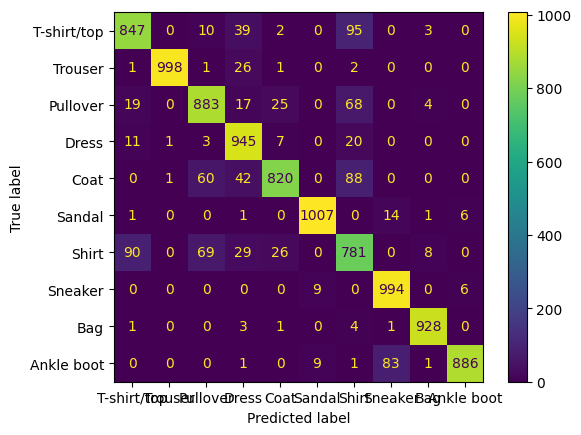



-------------------  Model 5, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:09<00:00, 82.58it/s]


Epoch: 1/20 | Train Loss: 0.41358561893863144 | Val Loss: 0.2980612678227911 | Val Accuracy: 0.8915 | LR: 0.0005
Best Val Loss: 0.2980612678227911 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:09<00:00, 83.50it/s]


Epoch: 2/20 | Train Loss: 0.273622895922045 | Val Loss: 0.24255888823680816 | Val Accuracy: 0.9104 | LR: 0.0005
Best Val Loss: 0.24255888823680816 | Saving state_dict...


...

Epoch: 8/20 | Train Loss: 0.1007900840866015 | Val Loss: 0.23940564381184093 | Val Accuracy: 0.9252 | LR: 0.0003


Epoch 9/20: 100%|██████████| 782/782 [00:08<00:00, 89.90it/s]


Epoch: 9/20 | Train Loss: 0.08360225415986289 | Val Loss: 0.2660826825222392 | Val Accuracy: 0.9202 | LR: 0.0003


Epoch 10/20: 100%|██████████| 782/782 [00:09<00:00, 83.37it/s]


Epoch: 10/20 | Train Loss: 0.06682853093501799 | Val Loss: 0.2645811528786068 | Val Accuracy: 0.9286 | LR: 0.0003
Early stopping triggered. Stopping after 10/20 epochs...
Total Training Time: 1.0m 47.05s
Model Training Done...



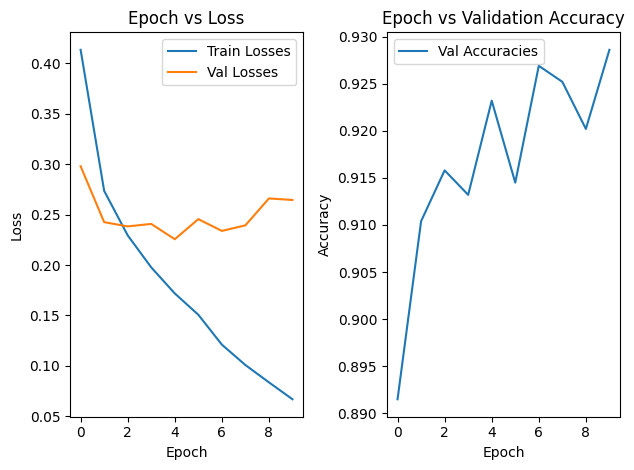

Running Validation...

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       996
           1       1.00      0.98      0.99      1029
           2       0.89      0.87      0.88      1016
           3       0.90      0.96      0.93       987
           4       0.93      0.84      0.88      1011
           5       0.98      0.98      0.98      1030
           6       0.80      0.78      0.79      1003
           7       0.98      0.94      0.96      1009
           8       0.98      1.00      0.99       938
           9       0.94      0.98      0.96       981

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

val Accuracy: 0.92 | val Loss: 0.2259


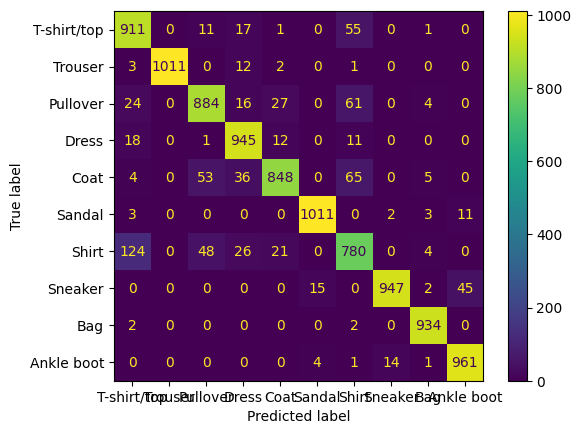



-------------------  Model 6, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:09<00:00, 80.19it/s]


Epoch: 1/20 | Train Loss: 0.4459091921139251 | Val Loss: 0.2895364553021018 | Val Accuracy: 0.8919 | LR: 0.0005
Best Val Loss: 0.2895364553021018 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:09<00:00, 84.12it/s]


Epoch: 2/20 | Train Loss: 0.3085656841297436 | Val Loss: 0.24957990684327047 | Val Accuracy: 0.9102 | LR: 0.0005
Best Val Loss: 0.24957990684327047 | Saving state_dict...


...

Epoch: 11/20 | Train Loss: 0.11610901291432131 | Val Loss: 0.2169659517373249 | Val Accuracy: 0.926 | LR: 0.0002


Epoch 12/20: 100%|██████████| 782/782 [00:09<00:00, 85.17it/s] 


Epoch: 12/20 | Train Loss: 0.10330966535403067 | Val Loss: 0.2153529796962905 | Val Accuracy: 0.9288 | LR: 0.0002


Epoch 13/20: 100%|██████████| 782/782 [00:09<00:00, 85.40it/s]


Epoch: 13/20 | Train Loss: 0.09236801444383724 | Val Loss: 0.21395928341491965 | Val Accuracy: 0.9321 | LR: 0.0001
Early stopping triggered. Stopping after 13/20 epochs...
Total Training Time: 2.0m 14.09s
Model Training Done...



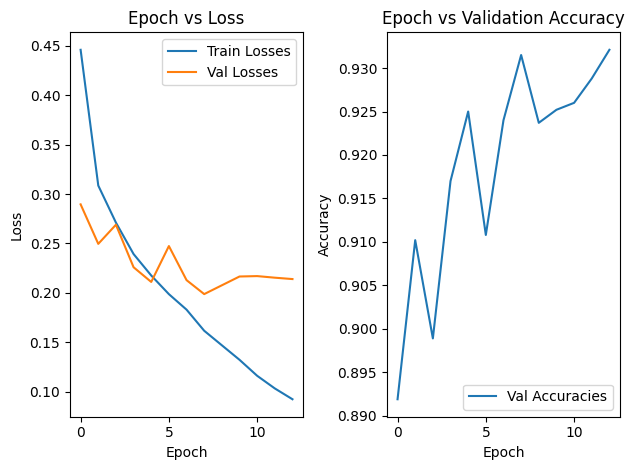

Running Validation...

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       996
           1       1.00      0.98      0.99      1029
           2       0.87      0.90      0.89      1016
           3       0.92      0.95      0.93       987
           4       0.88      0.92      0.90      1011
           5       0.98      0.99      0.99      1030
           6       0.83      0.78      0.80      1003
           7       0.98      0.96      0.97      1009
           8       0.99      0.99      0.99       938
           9       0.97      0.97      0.97       981

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

val Accuracy: 0.93 | val Loss: 0.1983


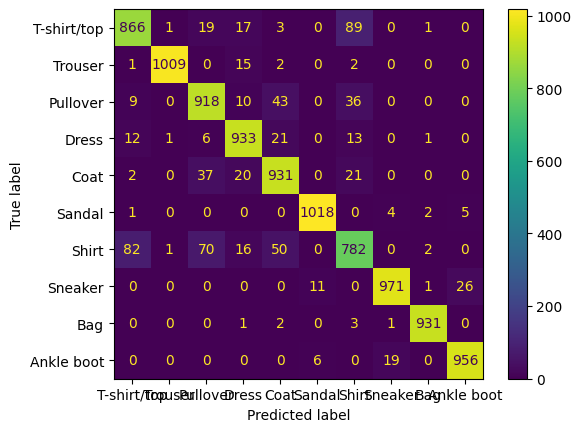



-------------------  Model 7, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:08<00:00, 88.29it/s]


Epoch: 1/20 | Train Loss: 0.47741513878411956 | Val Loss: 0.3003435924554327 | Val Accuracy: 0.8868 | LR: 0.0005
Best Val Loss: 0.3003435924554327 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:08<00:00, 91.05it/s]


Epoch: 2/20 | Train Loss: 0.32939226215567124 | Val Loss: 0.26083476903142444 | Val Accuracy: 0.9043 | LR: 0.0005
Best Val Loss: 0.26083476903142444 | Saving state_dict...


...

Epoch: 17/20 | Train Loss: 0.08152667570220845 | Val Loss: 0.20825955983559796 | Val Accuracy: 0.9344 | LR: 0.0000


Epoch 18/20: 100%|██████████| 782/782 [00:08<00:00, 89.00it/s]


Epoch: 18/20 | Train Loss: 0.07733957422004008 | Val Loss: 0.20629825205749766 | Val Accuracy: 0.9342 | LR: 0.0000


Epoch 19/20: 100%|██████████| 782/782 [00:09<00:00, 80.47it/s]


Epoch: 19/20 | Train Loss: 0.07483335602504518 | Val Loss: 0.20988605081275769 | Val Accuracy: 0.9352 | LR: 0.0000
Early stopping triggered. Stopping after 19/20 epochs...
Total Training Time: 3.0m 22.05s
Model Training Done...



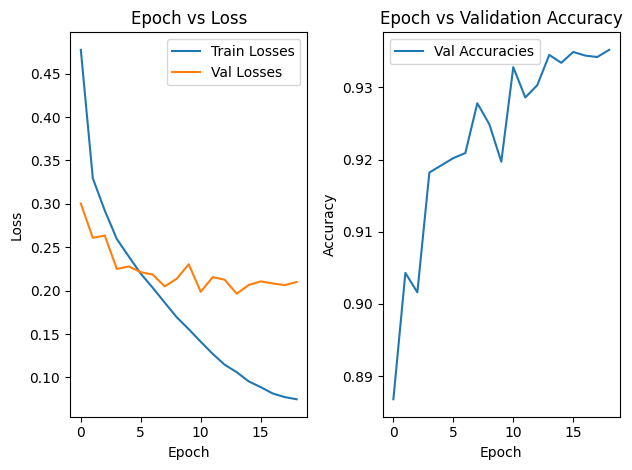

Running Validation...

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       996
           1       0.99      0.99      0.99      1029
           2       0.88      0.90      0.89      1016
           3       0.93      0.96      0.94       987
           4       0.89      0.91      0.90      1011
           5       0.99      0.99      0.99      1030
           6       0.83      0.78      0.80      1003
           7       0.97      0.98      0.97      1009
           8       0.99      0.99      0.99       938
           9       0.98      0.96      0.97       981

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

val Accuracy: 0.93 | val Loss: 0.1970


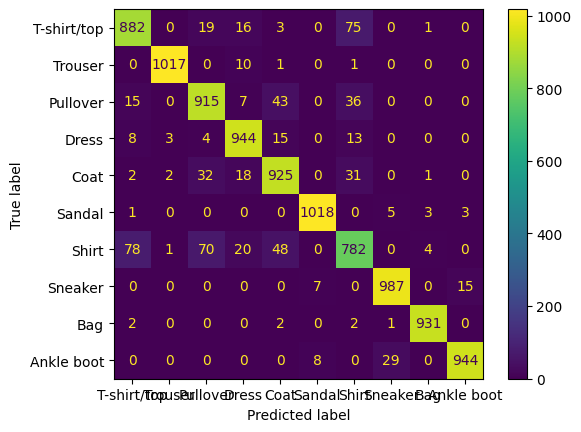



-------------------  Model 8, Optimizer 0  ---------------------


Epoch 1/20: 100%|██████████| 782/782 [00:10<00:00, 77.38it/s]


Epoch: 1/20 | Train Loss: 0.47318720042019546 | Val Loss: 0.31376653520544623 | Val Accuracy: 0.8879 | LR: 0.0005
Best Val Loss: 0.31376653520544623 | Saving state_dict...


Epoch 2/20: 100%|██████████| 782/782 [00:10<00:00, 77.77it/s]


Epoch: 2/20 | Train Loss: 0.29802382166695107 | Val Loss: 0.25758831008414557 | Val Accuracy: 0.9062 | LR: 0.0005
Best Val Loss: 0.25758831008414557 | Saving state_dict...


...

Epoch: 11/20 | Train Loss: 0.07887652741692712 | Val Loss: 0.24152001743293872 | Val Accuracy: 0.9254 | LR: 0.0002


Epoch 12/20: 100%|██████████| 782/782 [00:09<00:00, 83.92it/s]


Epoch: 12/20 | Train Loss: 0.06310857074749668 | Val Loss: 0.2501143979762865 | Val Accuracy: 0.9279 | LR: 0.0002


Epoch 13/20: 100%|██████████| 782/782 [00:10<00:00, 78.17it/s]


Epoch: 13/20 | Train Loss: 0.05049099745359891 | Val Loss: 0.27063098170195415 | Val Accuracy: 0.924 | LR: 0.0001
Early stopping triggered. Stopping after 13/20 epochs...
Total Training Time: 2.0m 24.95s
Model Training Done...



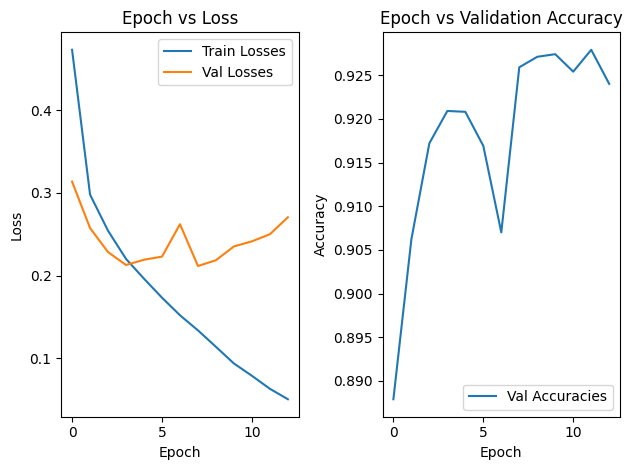

Running Validation...

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       996
           1       1.00      0.99      0.99      1029
           2       0.91      0.86      0.88      1016
           3       0.91      0.93      0.92       987
           4       0.85      0.92      0.88      1011
           5       0.98      0.98      0.98      1030
           6       0.79      0.81      0.80      1003
           7       0.95      0.98      0.97      1009
           8       0.99      0.99      0.99       938
           9       0.98      0.95      0.97       981

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

val Accuracy: 0.93 | val Loss: 0.2121


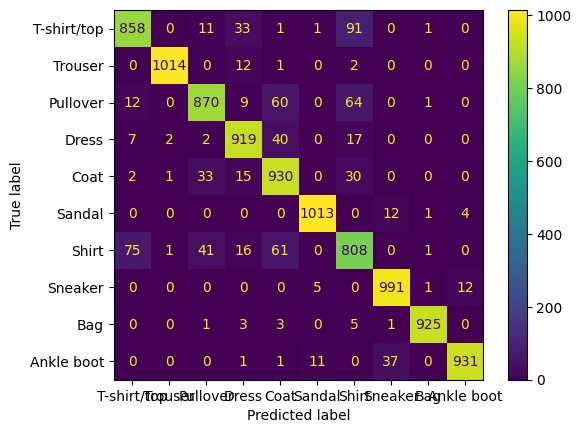

In [178]:
num_epochs = 20

for name, model in models.items():
    for optim_index, optim_fn in enumerate(model.optimizers):
        print(f"\n\n-------------------  {name}, Optimizer {optim_index}  ---------------------")
        reset_model_params(model)
        optimizer = optim_fn(params=model.parameters())
        try:
            lr_scheduler = model.lr_scheduler(optimizer, T_max=num_epochs, eta_min=1e-6)
        except AttributeError:
            lr_scheduler = None
        best_model_state, train_losses, val_losses, val_accs, best_val_loss, elapsed = train_model(model, num_epochs, criterion, optimizer, train_dataloader, val_dataloader, scheduler=lr_scheduler)

        print("Model Training Done...\n")
        plot_results(train_losses, val_losses, val_accs)

        print("Running Validation...\n")
        val_acc, val_loss = run_validation(model, best_model_state, val_dataloader, criterion)

        model_stats["Model"].append(name)
        model_stats["Optimizer"].append(f"Optimizer {optim_index}")
        model_stats["Val Accuracy"].append(val_acc)
        model_stats["Val Loss"].append(val_loss)
        model_stats["Train Time"].append(elapsed)


In [179]:
summary = pd.DataFrame(model_stats)
summary

,Model,Optimizer,Val Accuracy,Val Loss,Train Time
0,Model 1,Optimizer 0,0.9270,0.208946,97.174401
1,Model 2,Optimizer 0,0.8931,0.296614,175.062641
2,Model 2,Optimizer 1,0.9020,0.283702,183.449167
3,Model 2,Optimizer 2,0.8858,0.316232,162.175204
4,Model 3,Optimizer 0,0.8750,0.368658,185.477568
5,Model 4,Optimizer 0,0.9089,0.255383,170.120322
6,Model 5,Optimizer 0,0.9232,0.225851,107.052570
7,Model 6,Optimizer 0,0.9315,0.198256,134.087939
8,Model 7,Optimizer 0,0.9345,0.197008,202.051654
9,Model 8,Optimizer 0,0.9259,0.212144,144.952160


Model 7 seems most promising to me... At least according to Validation Loss.

### Next Steps:
* More models and optimizers
* Save validation loss into summary
* DO NOT SELECT MODELS BASED ON THEIR TEST ACCURACIES. REPLACE TEST ACCURACY IN SUMMARY WITH VALIDATION ACCURACY. THIS IS A SOURCE OF DATA LEAKAGE.
* Always use GPU when training these. All 8 different training loops of 15 epochs took a total of 21 minutes with T4 GPU. I did one full training of 15 epochs for model 6 yesterday for over 20 minutes.
* Implement Data Augmentation